# ALiBi — Attention with Linear Biases (Press et al., 2022)

ALiBi is the radical simplification of positional encoding: **don't encode position
in the embeddings at all.** Instead, subtract a linear distance penalty directly
from the attention scores.

This notebook covers:
1. The core idea — no PE, just a bias on attention scores
2. The per-head slope design and why it works
3. Implementation from scratch
4. Why ALiBi extrapolates better than anything before it
5. Comparison with RoPE — tradeoffs and when to use which

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## Part 1: The Core Idea — Beautifully Simple

Every other method we've seen modifies the **embeddings** or the **Q/K vectors** to inject
position. ALiBi does none of that. It adds a penalty directly to the attention scores:

$$\text{score}(i, j) = q_i \cdot k_j - m \cdot |i - j|$$

That's it. No sin/cos, no rotation, no learned embeddings. Just:
- Compute attention scores normally (pure content, no position info)
- Subtract `m × distance` from each score
- `m` is a fixed slope that's different per attention head

The penalty is **linear** in distance — token 10 positions away gets penalized 10× more
than a token 1 position away. This naturally makes the model attend more to nearby tokens.

Note: the original paper uses a causal (non-absolute) version: the bias is `-m × (i - j)`
for `j ≤ i` (only looking backward). Let's build both versions:

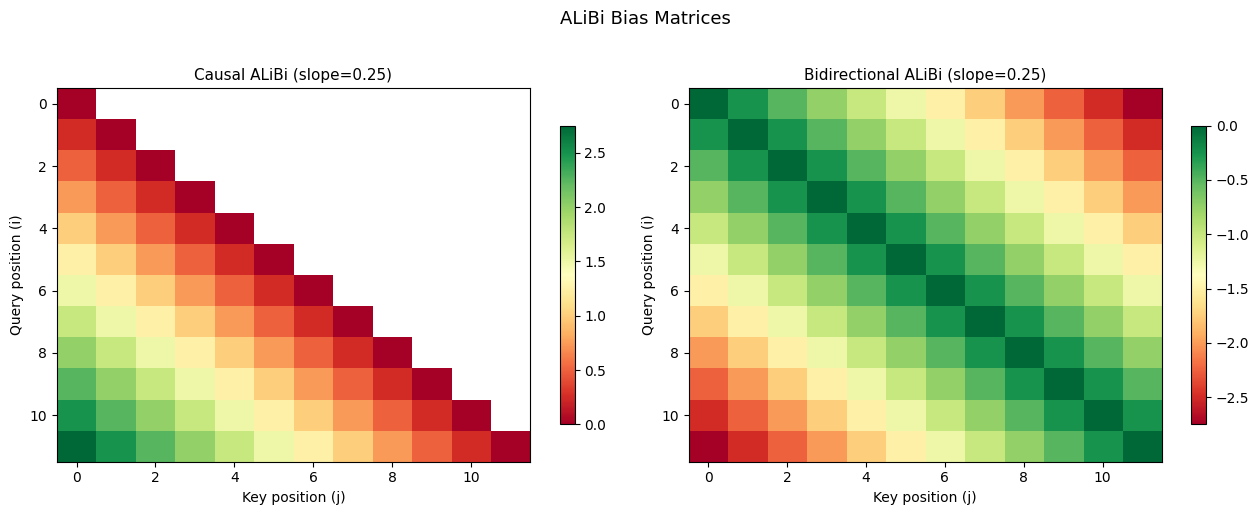

Green = small penalty (nearby tokens, attend strongly)
Red = large penalty (distant tokens, attend weakly)
Causal: upper triangle is -inf (can't attend to future)


In [2]:
def alibi_bias_causal(seq_len, slope):
    """
    Build the ALiBi bias matrix for a single head (causal / autoregressive).
    
    For query at position i and key at position j (where j <= i):
        bias[i, j] = -slope * (i - j)
    
    Returns: (seq_len, seq_len) tensor, upper triangle masked to -inf
    """
    # Distance matrix: i - j (non-negative for causal)
    positions = torch.arange(seq_len)
    distance = positions.unsqueeze(0) - positions.unsqueeze(1)  # (seq_len, seq_len)
    
    # Causal: only attend to past (j <= i), so distance >= 0
    bias = -slope * distance.float()
    
    # Mask future positions
    causal_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    bias = bias.masked_fill(causal_mask, float('-inf'))
    
    return bias

def alibi_bias_bidirectional(seq_len, slope):
    """
    ALiBi bias for bidirectional attention (like BERT).
    bias[i, j] = -slope * |i - j|
    """
    positions = torch.arange(seq_len)
    distance = (positions.unsqueeze(0) - positions.unsqueeze(1)).abs().float()
    return -slope * distance

# Visualize both
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seq_len = 12
slope = 0.25

causal = alibi_bias_causal(seq_len, slope)
bidirectional = alibi_bias_bidirectional(seq_len, slope)

# Replace -inf with NaN for visualization
causal_viz = causal.clone()
causal_viz[causal_viz == float('-inf')] = float('nan')

im0 = axes[0].imshow(causal_viz.numpy(), cmap='RdYlGn', aspect='auto')
axes[0].set_title(f'Causal ALiBi (slope={slope})', fontsize=11)
axes[0].set_xlabel('Key position (j)')
axes[0].set_ylabel('Query position (i)')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(bidirectional.numpy(), cmap='RdYlGn', aspect='auto')
axes[1].set_title(f'Bidirectional ALiBi (slope={slope})', fontsize=11)
axes[1].set_xlabel('Key position (j)')
axes[1].set_ylabel('Query position (i)')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.suptitle('ALiBi Bias Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Green = small penalty (nearby tokens, attend strongly)")
print("Red = large penalty (distant tokens, attend weakly)")
print("Causal: upper triangle is -inf (can't attend to future)")

## Part 2: The Per-Head Slopes — A Geometric Sequence

Each attention head gets a different slope `m`. The slopes are set as a geometric sequence:

$$m_h = \frac{1}{2^{8 \cdot h / H}}$$

where `h` is the head index (1 to H) and `H` is the total number of heads.

For 8 heads: `m = [1/2, 1/4, 1/8, 1/16, 1/32, 1/64, 1/128, 1/256]`

This creates a **spectrum of attention ranges**:
- Head with `m=1/2`: steep penalty → attends very locally (nearby tokens only)
- Head with `m=1/256`: gentle penalty → attends broadly (almost global attention)

The model gets both local and global attention patterns without learning anything!

In [ ]:
def get_alibi_slopes(n_heads):
    """
    Compute ALiBi slopes for each head.
    For n_heads that is a power of 2: geometric sequence from 2^(-8/n) to 2^(-8).
    """
    # The ratio between consecutive slopes
    ratio = 2 ** (-8.0 / n_heads)
    slopes = [ratio ** (i + 1) for i in range(n_heads)]
    return slopes

# Visualize slopes for different head counts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_heads, color in [(4, '#e74c3c'), (8, '#3498db'), (16, '#2ecc71'), (32, '#9b59b6')]:
    slopes = get_alibi_slopes(n_heads)
    axes[0].plot(range(n_heads), slopes, 'o-', label=f'{n_heads} heads', color=color, markersize=4)

axes[0].set_xlabel('Head index')
axes[0].set_ylabel('Slope (m)')
axes[0].set_title('ALiBi Slopes per Head')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Show what different slopes look like as attention patterns
seq_len = 32
slopes_8 = get_alibi_slopes(8)

selected = [0, 2, 5, 7]  # heads to visualize
for idx in selected:
    bias = alibi_bias_causal(seq_len, slopes_8[idx])
    # Look at query position 31 (last token) attending to all previous
    row = bias[seq_len-1, :seq_len].clone()
    row[row == float('-inf')] = float('nan')
    axes[1].plot(row.numpy(), label=f'Head {idx} (m={slopes_8[idx]:.4f})', linewidth=2)

axes[1].set_xlabel('Key position')
axes[1].set_ylabel('ALiBi bias')
axes[1].set_title('Bias from last token to all previous (different heads)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Head 0 (steep slope): only cares about the last few tokens")
print("Head 7 (gentle slope): can see the entire sequence almost equally")
print()
print("This is like having multiple 'zoom levels' built into the architecture:")
print("  Some heads do local syntax, others do global document understanding.")

## Part 3: Full ALiBi Attention — Implementation

Let's build a complete multi-head attention layer with ALiBi:

In [ ]:
class ALiBiMultiHeadAttention(nn.Module):
    """Multi-head attention with ALiBi positional biases."""
    
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        
        self.W_qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.W_out = nn.Linear(d_model, d_model, bias=False)
        
        # Pre-compute slopes (NOT learned — fixed forever)
        slopes = get_alibi_slopes(n_heads)
        self.register_buffer('slopes', torch.tensor(slopes).float())
    
    def forward(self, x, causal=True):
        batch, seq_len, _ = x.shape
        
        # Project to Q, K, V — NO position encoding added!
        qkv = self.W_qkv(x)
        Q, K, V = qkv.chunk(3, dim=-1)
        
        # Reshape to (batch, n_heads, seq_len, head_dim)
        Q = Q.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        
        # Content-based attention scores
        scores = Q @ K.transpose(-2, -1) / (self.head_dim ** 0.5)
        # shape: (batch, n_heads, seq_len, seq_len)
        
        # Build ALiBi bias: (n_heads, seq_len, seq_len)
        positions = torch.arange(seq_len, device=x.device)
        distance = positions.unsqueeze(0) - positions.unsqueeze(1)  # (seq_len, seq_len)
        
        if causal:
            # Causal: bias = -m * (i - j) for j <= i
            alibi = -self.slopes.unsqueeze(1).unsqueeze(1) * distance.unsqueeze(0).float()
            causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
            alibi = alibi.masked_fill(causal_mask.unsqueeze(0), float('-inf'))
        else:
            alibi = -self.slopes.unsqueeze(1).unsqueeze(1) * distance.abs().unsqueeze(0).float()
        
        # Add bias to scores
        scores = scores + alibi.unsqueeze(0)  # broadcast over batch
        
        weights = F.softmax(scores, dim=-1)
        output = weights @ V
        
        # Reshape back
        output = output.transpose(1, 2).contiguous().view(batch, seq_len, self.d_model)
        return self.W_out(output), weights, scores

# Test it
torch.manual_seed(42)
d_model = 64
n_heads = 8
seq_len = 20

model = ALiBiMultiHeadAttention(d_model, n_heads)
x = torch.randn(1, seq_len, d_model)
output, weights, scores = model(x, causal=True)

print(f"Input:  {x.shape}")
print(f"Output: {output.shape}")
print(f"Weights: {weights.shape}  (batch, heads, seq, seq)")
print(f"\nSlopes: {model.slopes.numpy().round(6)}")
print(f"\nNote: NO position embeddings anywhere in the model!")
print(f"The ONLY position signal comes from the ALiBi bias added to attention scores.")

### Visualizing attention patterns across heads

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for idx, ax in enumerate(axes.flat):
    w = weights[0, idx].detach().numpy()
    im = ax.imshow(w, cmap='Blues', aspect='auto', vmin=0)
    slope = model.slopes[idx].item()
    ax.set_title(f'Head {idx} (m={slope:.4f})', fontsize=10)
    ax.set_xlabel('Key pos')
    ax.set_ylabel('Query pos')

plt.suptitle('ALiBi: Attention Patterns Across 8 Heads (causal)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Head 0 (steep slope): very local — sharp diagonal, almost only attends to itself + neighbors")
print("Head 7 (gentle slope): broad — attends across the full sequence")
print()
print("The model automatically gets a spectrum from local to global attention,")
print("without learning a single positional parameter.")

## Part 4: Why ALiBi Extrapolates So Well

This is ALiBi's superpower. Let's see why.

With RoPE or sinusoidal PE, extrapolation fails because the model encounters
**unseen rotation angles or embedding patterns** beyond training length.

With ALiBi, the bias at distance `d` is just `-m × d`. There's nothing to "learn" about
distance 10,000 — it's just 10× the penalty of distance 1,000. The function is a straight
line, and a straight line extrapolates perfectly.

The model learns during training:
- "When the bias is -0.5, I should still pay some attention"
- "When the bias is -5.0, I should mostly ignore this token"

These learned thresholds work at ANY distance, because the bias is just a linear function.

Let's visualize this:

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_len = 1024
test_len = 4096
slope = 0.0625  # 1/16

# The bias function
distances_train = np.arange(train_len)
distances_test = np.arange(test_len)

bias_train = -slope * distances_train
bias_test = -slope * distances_test

axes[0].plot(distances_train, bias_train, color='#3498db', linewidth=2, label='Training range')
axes[0].plot(distances_test[train_len:], bias_test[train_len:], color='#e74c3c', 
             linewidth=2, linestyle='--', label='Extrapolated range')
axes[0].axvline(x=train_len, color='green', linestyle=':', alpha=0.7, label=f'Train boundary ({train_len})')
axes[0].set_xlabel('Distance |i - j|')
axes[0].set_ylabel('ALiBi bias')
axes[0].set_title('ALiBi: Bias is a straight line — extrapolates perfectly')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Compare with what RoPE's effective bias looks like
# RoPE's "bias" is implicit — the dot product of rotated vectors
# It oscillates and doesn't extrapolate smoothly
np.random.seed(42)
head_dim = 64
q = np.random.randn(head_dim)
k = np.random.randn(head_dim)

rope_scores = []
for d in range(test_len):
    score = 0
    for i in range(head_dim // 2):
        theta = 1.0 / (10000 ** (2 * i / head_dim))
        angle = d * theta
        # The relative-position component of the dot product
        score += q[2*i] * (k[2*i]*np.cos(angle) + k[2*i+1]*np.sin(angle))
        score += q[2*i+1] * (-k[2*i]*np.sin(angle) + k[2*i+1]*np.cos(angle))
    rope_scores.append(score / (head_dim ** 0.5))

# Smooth for visibility
window = 50
rope_smooth = np.convolve(rope_scores, np.ones(window)/window, mode='valid')

axes[1].plot(rope_smooth[:train_len], color='#3498db', linewidth=1, alpha=0.7, label='RoPE (training)')
axes[1].plot(np.arange(train_len, len(rope_smooth)), rope_smooth[train_len:], 
             color='#e74c3c', linewidth=1, alpha=0.7, label='RoPE (extrapolated)')
axes[1].axvline(x=train_len, color='green', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Relative distance')
axes[1].set_ylabel('Effective score contribution')
axes[1].set_title('RoPE: Oscillating, complex extrapolation behavior')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Why ALiBi Extrapolates Better Than RoPE', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

print("ALiBi (left): a straight line. Distance 5000 is just 5× the penalty of distance 1000.")
print("  The model's learned 'attention threshold' works at any distance.")
print()
print("RoPE (right): oscillating, complex pattern. The model learned to interpret specific")
print("  oscillation patterns during training. Beyond training length, the patterns change")
print("  in ways the model hasn't seen → degraded performance.")

## Part 5: ALiBi vs RoPE — The Tradeoffs

ALiBi extrapolates better out of the box, so why did the industry converge on RoPE?

Let's explore the tradeoffs:

In [ ]:
# Tradeoff 1: Expressiveness
# ALiBi can only express "closer = more important" (monotonic decay)
# RoPE can express arbitrary relative position patterns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ALiBi: always monotonic decay
distances = np.arange(50)
for slope in [0.5, 0.1, 0.02]:
    softmax_input = -slope * distances
    # Normalize to show relative attention
    attn = np.exp(softmax_input) / np.exp(softmax_input).sum()
    axes[0].plot(distances, attn, linewidth=2, label=f'm={slope}')
axes[0].set_title('ALiBi: Always monotonic decay', fontsize=11)
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Relative attention weight')
axes[0].legend(fontsize=9)

# RoPE: can learn non-monotonic patterns
# e.g., "attend strongly to distance 5" (like a specific syntactic pattern)
np.random.seed(42)
# Simulate a trained RoPE model that learned to attend at specific distances
x = np.arange(50)
pattern1 = np.exp(-0.05 * x) * (1 + 0.5 * np.cos(0.5 * x))  # oscillating decay
pattern2 = np.exp(-0.02 * x) * (1 + np.exp(-((x-10)**2)/8))  # bump at distance 10
axes[1].plot(x, pattern1 / pattern1.sum(), linewidth=2, label='Oscillating pattern')
axes[1].plot(x, pattern2 / pattern2.sum(), linewidth=2, label='Bump at distance 10')
axes[1].set_title('RoPE: Can learn complex patterns', fontsize=11)
axes[1].set_xlabel('Distance')
axes[1].set_ylabel('Relative attention weight')
axes[1].legend(fontsize=9)

# Summary comparison
categories = ['Extrapolation', 'Expressiveness', 'Simplicity', 'KV-Cache', 'No Extra\nParams']
alibi_scores = [5, 2, 5, 5, 5]
rope_scores = [3, 5, 4, 5, 5]

x_pos = np.arange(len(categories))
width = 0.35
axes[2].bar(x_pos - width/2, alibi_scores, width, label='ALiBi', color='#3498db', alpha=0.8)
axes[2].bar(x_pos + width/2, rope_scores, width, label='RoPE', color='#e74c3c', alpha=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(categories, fontsize=8)
axes[2].set_ylabel('Score (1-5)')
axes[2].set_title('ALiBi vs RoPE: Tradeoffs', fontsize=11)
axes[2].legend()
axes[2].set_ylim(0, 6)

plt.tight_layout()
plt.show()

print("ALiBi wins on: extrapolation, simplicity")
print("RoPE wins on: expressiveness (can learn non-monotonic attention patterns)")
print()
print("In practice, RoPE's expressiveness matters more for complex reasoning tasks.")
print("And with NTK/YaRN scaling, RoPE's extrapolation gap has been largely closed.")
print("That's why most modern LLMs chose RoPE over ALiBi.")

## Part 6: The Softmax Interaction — Why Linear Bias Works

A subtle but important point: the linear bias interacts with softmax in a specific way.

After softmax, the attention weight for key at distance `d` is proportional to:

$$\alpha_d \propto \exp(s_d - m \cdot d)$$

where $s_d$ is the content-based score. This means the effective attention weight
**decays exponentially** with distance (not linearly!):

$$\alpha_d \propto \exp(s_d) \cdot \exp(-m \cdot d) = \text{content\_weight} \times e^{-md}$$

A linear bias in logit space becomes an **exponential decay** in probability space.
This is actually a very natural model of attention — exponential decay with distance
is common in many physical and linguistic phenomena.

In [ ]:
# Show the linear-to-exponential transformation through softmax
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

seq_len = 50
distances = np.arange(seq_len)
slope = 0.1

# Step 1: Content scores (random, no position info)
np.random.seed(42)
content_scores = np.random.randn(seq_len) * 0.5

# Step 2: Add ALiBi bias (linear)
alibi_bias = -slope * distances
biased_scores = content_scores + alibi_bias

# Step 3: Softmax
def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

weights_no_alibi = softmax(content_scores)
weights_with_alibi = softmax(biased_scores)

axes[0].bar(distances, content_scores, color='#3498db', alpha=0.7, label='Content scores')
axes[0].plot(distances, alibi_bias, color='#e74c3c', linewidth=2, label='ALiBi bias (linear)')
axes[0].set_title('Before softmax: linear bias', fontsize=11)
axes[0].set_xlabel('Key position (distance from query)')
axes[0].legend(fontsize=9)

axes[1].bar(distances, weights_no_alibi, color='#3498db', alpha=0.5, label='Without ALiBi')
axes[1].bar(distances, weights_with_alibi, color='#e74c3c', alpha=0.5, label='With ALiBi')
axes[1].set_title('After softmax: exponential decay', fontsize=11)
axes[1].set_xlabel('Key position')
axes[1].set_ylabel('Attention weight')
axes[1].legend(fontsize=9)

# Show the pure exponential decay factor
exp_decay = np.exp(-slope * distances)
exp_decay /= exp_decay.sum()
axes[2].plot(distances, exp_decay, color='#e74c3c', linewidth=2, label=f'exp(-{slope}×d)')
axes[2].fill_between(distances, exp_decay, alpha=0.2, color='#e74c3c')
axes[2].set_title('Pure distance decay factor', fontsize=11)
axes[2].set_xlabel('Distance')
axes[2].set_ylabel('Decay weight')
axes[2].legend()

plt.suptitle('ALiBi: Linear in logits → Exponential in probabilities', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

print("The linear bias creates an exponential attention window.")
print(f"With slope m={slope}:")
print(f"  Distance 1:  decay = {np.exp(-slope*1):.3f} (93% of adjacent)")
print(f"  Distance 10: decay = {np.exp(-slope*10):.3f}")
print(f"  Distance 50: decay = {np.exp(-slope*50):.6f}")
print()
print("Content can override the decay — a very relevant distant token can still")
print("get high attention if its content score is high enough to overcome the penalty.")

## Summary

| Aspect | ALiBi |
|--------|-------|
| Position signal | Linear bias on attention scores, no embedding modification |
| Parameters | Zero — slopes are fixed, not learned |
| Extrapolation | Excellent — linear function generalizes trivially |
| Expressiveness | Limited — can only express monotonic distance decay |
| Per-head behavior | Different slopes → spectrum from local to global attention |
| Softmax interaction | Linear bias → exponential decay in attention weights |
| KV-cache | Fully compatible — bias depends only on distance |
| Used by | BLOOM, MPT |

### Why RoPE won over ALiBi in the end:
1. RoPE can learn **non-monotonic** attention patterns (e.g., attend to a specific relative position)
2. RoPE's scaling techniques (NTK, YaRN) closed the extrapolation gap
3. RoPE preserves more information — it modifies Q/K without losing any dimensions
4. Empirically, RoPE models performed better on complex reasoning benchmarks

### ALiBi's lasting contribution:
The insight that **you don't need to modify embeddings at all** — position can be a pure
attention-score bias — influenced later work and showed that simpler approaches can be
surprisingly effective. It also demonstrated that extrapolation should be a primary design goal,
pushing the field toward the RoPE scaling techniques that followed.